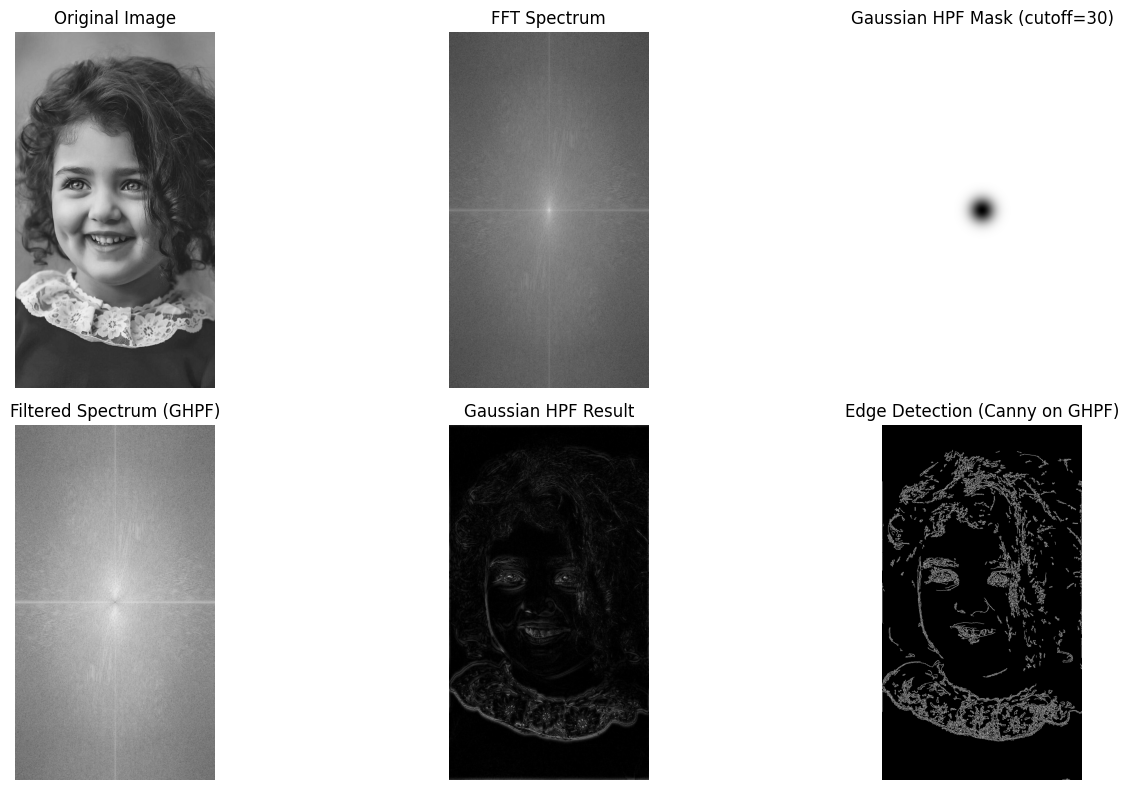

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1️⃣ Read image (grayscale) ---
img = cv2.imread('pk.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("❌ Image not found. Please make sure 'pk.jpg' exists in this folder.")

# --- 2️⃣ Apply FFT ---
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

# --- 3️⃣ Define Gaussian High Pass Filter ---
def gaussian_highpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(rows)
    v = np.arange(cols)
    V, U = np.meshgrid(v, u)
    D = np.sqrt((U - crow)**2 + (V - ccol)**2)
    H = 1 - np.exp(-(D**2) / (2 * (cutoff**2)))  # High-pass version
    return H

# --- 4️⃣ Create Filter Mask ---
cutoff = 30  # Change for different strength (10, 30, 60)
H_ghpf = gaussian_highpass(img.shape, cutoff)

# --- 5️⃣ Apply Gaussian High Pass Filter ---
F_ghpf = fshift * H_ghpf

# --- 6️⃣ Inverse FFT to get filtered image ---
ghpf_img = np.abs(np.fft.ifft2(np.fft.ifftshift(F_ghpf)))

# --- 7️⃣ Normalize for display ---
ghpf_img = cv2.normalize(ghpf_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# --- 8️⃣ Edge Detection using High Pass output ---
edges = cv2.Canny(ghpf_img, 50, 150)

# --- 9️⃣ Display Results ---
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.abs(fshift)), cmap='gray')
plt.title('FFT Spectrum')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(H_ghpf, cmap='gray')
plt.title(f'Gaussian HPF Mask (cutoff={cutoff})')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(np.log(1 + np.abs(F_ghpf)), cmap='gray')
plt.title('Filtered Spectrum (GHPF)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(ghpf_img, cmap='gray')
plt.title('Gaussian HPF Result')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection (Canny on GHPF)')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np

image = cv2.imread('pk.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2.imshow("Original", image)

#--------------------<Erosion>--------------------#
eroded = ()
for i in range(0, 3):
    _ =  (cv2.erode(gray.copy(), None, iterations=i + 1), )
    eroded += _
cv2.imshow("Eroded images ({})".format(len(eroded)), np.hstack(eroded))

#--------------------<Dilation>--------------------#
dilated = ()
for i in range(0, 3):
    _ = (cv2.dilate(gray.copy(), None, iterations=i + 1),)
    dilated += _
cv2.imshow("Dilated images ({})".format(len(dilated)), np.hstack(dilated))

#--------------------<Opening>--------------------#
kernelSizes = [(3, 3), (5, 5), (7, 7)]
openings = ()
# loop over the kernels sizes
for kernelSize in kernelSizes:
# construct a rectangular kernel from the current size and then
# apply an "opening" operation
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    _ = (cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel),)
    openings += _
cv2.imshow("Openings images ({})".format(kernelSizes), np.hstack(openings))

#--------------------<Closing>--------------------#
closings = ()
for kernelSize in kernelSizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    _ =  (cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel),)
    closings += _
cv2.imshow("Closing images ({})".format(kernelSizes), np.hstack(closings))

#--------------------<Morphological gradient>--------------------#
gradient = ()
for kernelSize in kernelSizes:
# construct a rectangular kernel and apply a "morphological
# gradient" operation to the image
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    _ = (cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel),)
    gradient += _
cv2.imshow("Morphological gradient ({})".format(kernelSizes), np.hstack(gradient))

#--------------------<Top hat/white hat and black hat>--------------------#

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# construct a rectangular kernel (13x5) and apply a blackhat
# operation which enables us to find dark regions on a light
# background
rectKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, rectKernel)
tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, rectKernel)
cv2.imshow("Black Hat\t\t\tTop Hat", np.hstack((blackhat, tophat)))

cv2.waitKey(0)
cv2.destroyAllWindows()